In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bar
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime

from TtoGmodel_15 import TextToGraphTransformer

In [3]:
from Circuits import Circuits
circuits= Circuits()

Loading dataset files...
Loaded dataset files successfully.


In [4]:
print(circuits.component_lists[0])
print(circuits.graphs[0])

['VDD', 'VSS', 'VIN1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [5]:
def collate_fn(batch):
    seqs, mats = zip(*batch)

    # Convert sequences to torch tensors
    seqs = [torch.tensor(seq, dtype=torch.long) for seq in seqs]

    # Convert adjacency matrices (NumPy -> PyTorch)
    mats = [torch.tensor(mat, dtype=torch.float32) for mat in mats]

    # Get max sizes
    max_seq_len = max(len(seq) for seq in seqs)
    max_nodes = max(mat.size(0) for mat in mats)

    # Pad sequences
    padded_seqs = torch.stack([
        F.pad(seq, (0, max_seq_len - len(seq)), value=0)
        for seq in seqs
    ])

    # Pad adjacency matrices
    padded_mats = torch.stack([
        F.pad(mat, (0, max_nodes - mat.size(1), 0, max_nodes - mat.size(0)), value=0)
        for mat in mats
    ])

    seq_lengths = torch.tensor([len(seq) for seq in seqs])

    return padded_seqs, padded_mats, seq_lengths


In [6]:
#dataset = list(zip(circuits.component_indices, circuits.graphs))
#loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

from sklearn.model_selection import train_test_split
import torch

# Assuming 'dataset' is already created as:
dataset = list(zip(circuits.component_indices, circuits.graphs))

# 80% Train, 20% Test split
train_data, test_data = train_test_split(dataset, test_size=0.1, random_state=42)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=16,
    shuffle=False,  # typically don't shuffle test data
    collate_fn=collate_fn
)


In [7]:
# Get the first batch of data from train_loader
first_batch = next(iter(train_loader))

# Unpack the batch
input_seqs, adj_mats, seq_lengths = first_batch

# Print the first batch details
#print("Input Sequences:", input_seqs)
#print("Adjacency Matrices:", adj_mats)
print("Sequence Lengths:", seq_lengths)
print("Input Sequences Shape:", input_seqs.shape)
print("Adjacency Matrices Shape:", adj_mats.shape)
print("Input Sequences Lengths:", [len(seq) for seq in input_seqs])
print("Adjacency Matrices Lengths:", [mat.shape for mat in adj_mats])



Sequence Lengths: tensor([ 71,  95,  74,  41, 141,  97,  97, 142, 144, 196,  77, 123,  47, 103,
         82,  36])
Input Sequences Shape: torch.Size([16, 196])
Adjacency Matrices Shape: torch.Size([16, 196, 196])
Input Sequences Lengths: [196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 196]
Adjacency Matrices Lengths: [torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196]), torch.Size([196, 196])]


In [8]:
#Da
print(circuits.component_indices[0])
print(circuits.graphs[0])


[376, 486, 565, 386, 542, 408, 190, 32]
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [9]:
# Initialize model parameters
vocab_size = len(circuits.vocab)  # Number of unique components
embedding_dim = 128
hidden_dim = 256
num_heads = 8
num_layers = 4
dropout = 0.1

# Initialize the model
model = TextToGraphTransformer(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

TextToGraphTransformer(
  (embedding): Embedding(892, 128, padding_idx=0)
  (positional_encoding): SinusoidalPositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): R

C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\1035239676.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 [Training]:   0%|          | 0/189 [00:00<?, ?it/s]C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\1035239676.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\1035239676.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1] 🛠️ Train Loss: 2.7424
[Epoch 1] 🔍 Test Loss: 2.0730


[Epoch 2] 🛠️ Train Loss: 2.2398
[Epoch 2] 🔍 Test Loss: 1.7656


[Epoch 3] 🛠️ Train Loss: 1.9722
[Epoch 3] 🔍 Test Loss: 1.5153


[Epoch 4] 🛠️ Train Loss: 1.7234
[Epoch 4] 🔍 Test Loss: 1.3155


...

[Epoch 26] 🛠️ Train Loss: 0.5422
[Epoch 26] 🔍 Test Loss: 0.4360


[Epoch 27] 🛠️ Train Loss: 0.5222
[Epoch 27] 🔍 Test Loss: 0.4278


[Epoch 28] 🛠️ Train Loss: 0.5095
[Epoch 28] 🔍 Test Loss: 0.4280
⚠️ No improvement for 1 epochs.


[Epoch 29] 🛠️ Train Loss: 0.5158
[Epoch 29] 🔍 Test Loss: 0.4150


[Epoch 30] 🛠️ Train Loss: 0.4946
[Epoch 30] 🔍 Test Loss: 0.4068
💾 Checkpoint saved at epoch 30 → Saves/TtoGmodel_epoch30_20250503_101329.pth


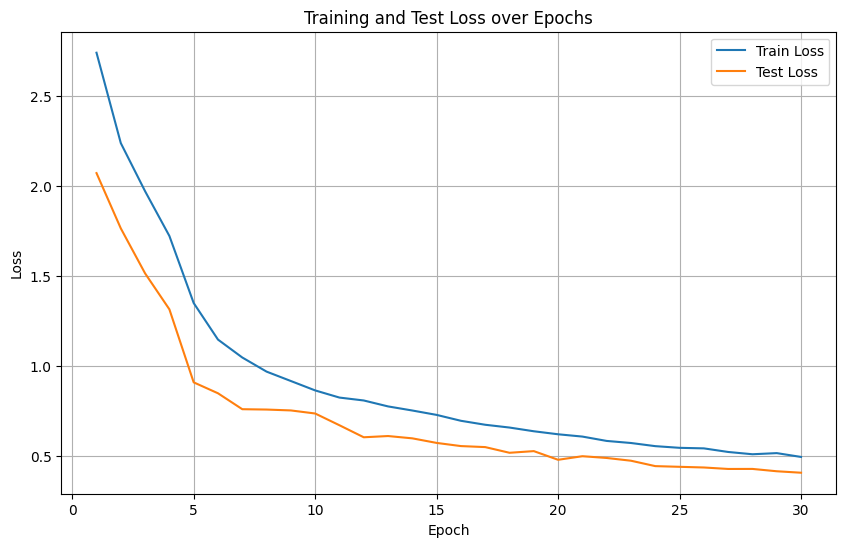

In [10]:
#Training Loop with dynamic pos_weight
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler
from datetime import datetime

PAD_TOKEN_ID = 0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()

num_epochs = 30
save_every = 10
early_stop_patience = 5  # Stop after 5 epochs of no improvement

train_losses = []
test_losses = []

best_test_loss = float('inf')
epochs_no_improve = 0

for epoch in range(1, num_epochs + 1):
    # ========== Training ==========    
    model.train()
    total_train_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch} [Training]", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        # Calculate pos_weight dynamically based on sequence length
        seq_length = seq_lengths.float().mean().item()  
        #pos_weight_value = (seq_length - 3) / 3  # Formula: pos_weight = (len - 3) / 3
        #pos_weight_value = max(pos_weight_value, 0.1)  # Ensure pos_weight doesn't go below 0.1
        #pos_weight = torch.tensor([pos_weight_value]).to(device)
        #print(f"Dynamic pos_weight: {pos_weight_value}")

        # Calculate the average number of zeros and ones in adj_mats
        num_elements = adj_mats.numel()
        num_ones = adj_mats.sum().item()
        num_zeros = num_elements - num_ones

        # Calculate pos_weight as the ratio of zeros to ones
        pos_weight_value = num_zeros / max(num_ones, 1)  # Avoid division by zero
        pos_weight_value = max(2*pos_weight_value, 0.1)
        pos_weight = torch.tensor([pos_weight_value]).to(device)



        # Define criterion with the dynamic pos_weight
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        optimizer.zero_grad()

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.detach().item()
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"[Epoch {epoch}] 🛠️ Train Loss: {avg_train_loss:.4f}")

    # ========== Evaluation ==========    
    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device, non_blocking=True)
            adj_mats = adj_mats.to(device, non_blocking=True)
            seq_lengths = seq_lengths.to(device, non_blocking=True)

            # Calculate pos_weight dynamically based on sequence length
            seq_length = seq_lengths.float().mean().item() 
            #pos_weight_value = (seq_length - 3) / 3  # Formula: pos_weight = (len - 3) / 3
            #pos_weight_value = max(pos_weight_value, 0.1)  # Ensure pos_weight doesn't go below 0.1
            #pos_weight = torch.tensor([pos_weight_value]).to(device)

            # Calculate the average number of zeros and ones in adj_mats
            num_elements = adj_mats.numel()
            num_ones = adj_mats.sum().item()
            num_zeros = num_elements - num_ones

            # Calculate pos_weight as the ratio of zeros to ones
            pos_weight_value = num_zeros / max(num_ones, 1)  # Avoid division by zero
            pos_weight = torch.tensor([pos_weight_value]).to(device)


            # Define criterion with the dynamic pos_weight
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            with autocast():
                seq_mask = (input_seqs != PAD_TOKEN_ID)
                predicted_logits = model(input_seqs, seq_mask)

                mask = (input_seqs != PAD_TOKEN_ID)
                mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
                mask_flat = mask2d.view(-1)
                pred_flat = predicted_logits.view(-1)
                true_flat = adj_mats.view(-1)

                loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

            total_test_loss += loss.detach().item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    print(f"[Epoch {epoch}] 🔍 Test Loss: {avg_test_loss:.4f}")

    # ========== Early Stopping Check ==========    
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epochs.")
        if epochs_no_improve >= early_stop_patience:
            print(f"⛔ Early stopping triggered at epoch {epoch}!")
            break

    # ========== Save Checkpoint ==========    
    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"Saves/TtoGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")

# Save final model
torch.save(model.state_dict(), 'TextToGraphTransformer.pth')

# ========== Plotting Loss ==========    
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(test_losses)+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


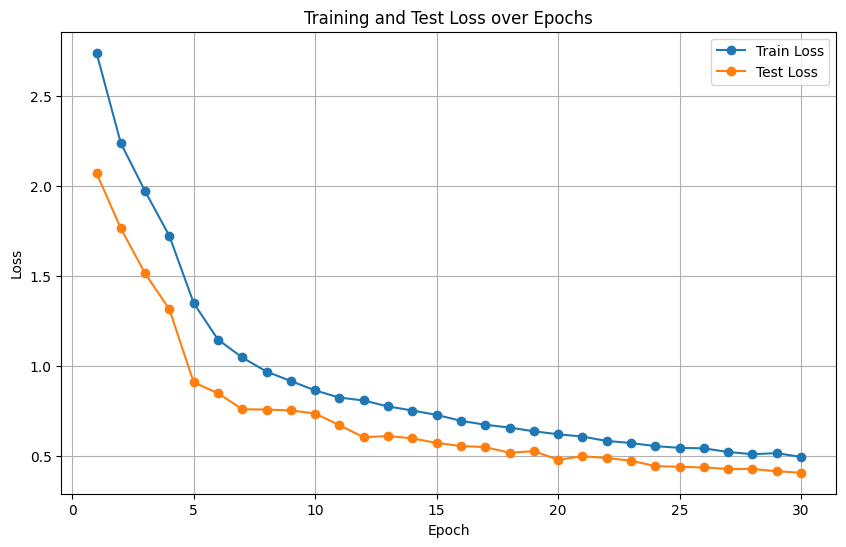

In [11]:
#Plotting Loss
import matplotlib.pyplot as plt
# ========== Plotting Loss ==========    
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss',marker='o')
plt.plot(range(1, len(test_losses)+1), test_losses, label='Test Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Model Loading Code
import torch

# Function to load model from a checkpoint file
def load_checkpoint(checkpoint_name, device='cpu'):
    checkpoint_path = f"Saves/{checkpoint_name}"
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Read saved hyperparameters
    vocab_size = checkpoint['vocab_size']
    embedding_dim = checkpoint['embedding_dim']
    hidden_dim = checkpoint['hidden_dim']
    num_heads = checkpoint['num_heads']
    num_layers = checkpoint['num_layers']
    dropout = checkpoint['dropout']
    learning_rate = checkpoint['learning_rate']
    
    # Initialize the model with saved hyperparameters
    model = TextToGraphTransformer(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    )
    model.to(device)
    
    # Initialize optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize scheduler (optional, based on your training setup)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    # Load model and optimizer states
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Load scheduler state (optional: check if it exists)
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    else:
        scheduler = None  # if you didn't save scheduler

    epoch = checkpoint['epoch']

    print(f"Checkpoint loaded from {checkpoint_path} (Epoch {epoch})")
    
    return model, optimizer, scheduler, epoch

# Example usage
load_the_model = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if load_the_model:
    checkpoint_name = 'TtoGmodel_epoch30_20250428_160701.pth'

    # Load the model, optimizer, scheduler, and training epoch
    model, optimizer, scheduler, epoch = load_checkpoint(checkpoint_name, device=device)

    # Now you can resume training or evaluation


Checkpoint loaded from Saves/TtoGmodel_epoch30_20250428_160701.pth (Epoch 30)


In [25]:
threshold = 0.99  # Since BCEWithLogitsLoss was used, apply sigmoid + threshold

In [40]:
#Training Loop with dynamic pos_weight and debugging print outputs
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler
from datetime import datetime

PAD_TOKEN_ID = 0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()

num_epochs = 1
save_every = 10
early_stop_patience = 5  # Stop after 5 epochs of no improvement

train_losses = []
test_losses = []

best_test_loss = float('inf')
epochs_no_improve = 0

output_file = "output.txt"
first_example_logged = False
example_no = 1

for epoch in range(1, num_epochs + 1):
    # ========== Training ==========    
    model.train()
    total_train_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch} [Training]", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        if not first_example_logged:
            with open(output_file, "a") as f:
                f.write(f"Example {example_no}:\n")
                #f.write(f"Input Sequence: {input_seqs[0].cpu().numpy()}\n")
                #f.write(f"Adjacency Matrix: {adj_mats[0].cpu().numpy()}\n")
                #f.write(f"Sequence Lengths: {seq_lengths.cpu().numpy()}\n")

                f.write(f"Input Sequence shape: {list(input_seqs[0].shape)}\n")
                f.write(f"Adjacency Matrix shape: {list(adj_mats[0].shape)}\n")
                f.write(f"Sequence Lengths shape: {list(seq_lengths.shape)}\n")

        # Calculate pos_weight dynamically based on sequence length
        seq_length = seq_lengths.float().mean().item()  # Calculate the average sequence length
        
        #There can be 1,2,3,4 connections so the most there can be are 4 connections
        #But most of the time there are 2 connections
        #pos_weight_value = (seq_length - 2) / 2  # Formula: pos_weight = (len - 2) / 2
        #pos_weight_value = max(pos_weight_value, 1)  # Ensure pos_weight doesn't go below 0.1
        #pos_weight = torch.tensor([pos_weight_value]).to(device)
        #print(f"Dynamic pos_weight: {pos_weight_value}")

        #if not first_example_logged:
        #    with open(output_file, "a") as f:
        #        f.write(f"Example {example_no}:\n")
        #        f.write(f"Input Sequence: {seq_length}\n")
        #        f.write(f"First method for pos_weight: {pos_weight_value}\n")
        #        f.write(f"--------------------------------------------------")


        # Calculate the average number of zeros and ones in adj_mats
        num_elements = adj_mats.numel()
        num_ones = adj_mats.sum().item()
        num_zeros = num_elements - num_ones

        # Calculate pos_weight as the ratio of zeros to ones
        pos_weight_value = num_zeros / max(num_ones, 1)  # Avoid division by zero
        pos_weight = torch.tensor([pos_weight_value]).to(device)

        #if not first_example_logged:
        #    with open(output_file, "a") as f:
        #        f.write(f"Example {example_no}:\n")
        #        f.write(f"number of elements: {num_elements}\n")
        #        f.write(f"num_ones: {num_ones}\n")
        #        f.write(f"num_zeros: {num_zeros}\n")
        #        f.write(f"Second method for pos_weight: {pos_weight_value}\n")
        #        f.write(f"--------------------------------------------------")

        # Define criterion with the dynamic pos_weight
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        optimizer.zero_grad()

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
                    
            predicted_logits = model(input_seqs, seq_mask)
            
            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

            if not first_example_logged:
                with open(output_file, "a") as f:
                    f.write(f"--------------------------------------------------\n")
                    f.write(f"Input Sequence: \n{input_seqs[0].cpu().numpy()}\n")
                    f.write(f"Input Sequence shape: {list(input_seqs[0].shape)}\n")
                    f.write(f"seq_mask: \n{seq_mask[0].cpu().numpy()}\n")
                    f.write(f"seq_mask shape: {list(seq_mask[0].shape)}\n")
                    f.write(f"predicted_logits: \n{predicted_logits[0].cpu().detach().numpy()}\n")
                    f.write(f"predicted_logits shape: {list(predicted_logits[0].shape)}\n")
                    f.write(f"mask: \n{mask[0].cpu().numpy()}\n")
                    f.write(f"mask shape: {list(mask[0].shape)}\n")
                    f.write(f"mask2d: row 1\n{mask2d[0][0].cpu().numpy()}\n")
                    f.write(f"mask2d: row 100\n{mask2d[0][99].cpu().numpy()}\n")
                    f.write(f"mask2d shape: {list(mask2d[0].shape)}\n")
                    f.write(f"mask_flat: \n{mask_flat.cpu().numpy()}\n")
                    f.write(f"mask_flat shape: {list(mask_flat.shape)}\n")
                    f.write(f"pred_flat: \n{pred_flat.cpu().detach().numpy()}\n")
                    f.write(f"pred_flat shape: {list(pred_flat.shape)}\n")
                    f.write(f"true_flat: \n{true_flat.cpu().numpy()}\n")
                    f.write(f"true_flat shape: {list(true_flat.shape)}\n")
                    f.write(f"Loss: \n{loss.item()}\n")
                    f.write(f"--------------------------------------------------\n")

                    first_example_logged = True

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Print tabular for first example
        if not first_example_logged:
            with open(output_file, "a") as f:
                #f.write(f"Example {example_no}:\n")
                #f.write(f"Input Sequence: {input_seqs[0].cpu().numpy()}\n")
                #f.write(f"Adjacency Matrix: {adj_mats[0].cpu().numpy()}\n")
                #f.write(f"Sequence Lengths: {seq_lengths.cpu().numpy()}\n")

                #f.write(f"Input Sequence shape: {list(input_seqs[0].shape)}\n")
                #f.write(f"Adjacency Matrix shape: {list(adj_mats[0].shape)}\n")
                #f.write(f"Sequence Lengths shape: {list(seq_lengths.shape)}\n")


                #f.write(f"Input Sequence: {seq_length}\n")
                #f.write(f"pos weight: {pos_weight.cpu().numpy()}\n")
                f.write(f"pos weight value: {pos_weight_value}\n")

                #f.write(f"Input Sequence: {input_seqs[0].cpu().numpy()}\n")
                #f.write(f"Adjacency Matrix: {adj_mats[0].cpu().numpy()}\n")
                #f.write("Adjacency Matrix (Full):\n")
                #f.write("\n".join(["\t".join(map(str, row.cpu().numpy())) for row in adj_mats[0]]))
                #f.write("\n")
                #f.write(f"Predicted Logits: {predicted_logits[0]}\n")
                #f.write(f"Loss: {loss.item()}\n\n")
            
            first_example_logged = True

        example_no += 1

        total_train_loss += loss.detach().item()
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"[Epoch {epoch}] 🛠️ Train Loss: {avg_train_loss:.4f}")

    # ========== Evaluation ==========    
    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device, non_blocking=True)
            adj_mats = adj_mats.to(device, non_blocking=True)
            seq_lengths = seq_lengths.to(device, non_blocking=True)

            # Calculate pos_weight dynamically based on sequence length
            seq_length = input_seqs.size(1)
            pos_weight_value = (seq_length - 3) / 3  # Formula: pos_weight = (len - 3) / 3
            pos_weight_value = max(pos_weight_value, 0.1)  # Ensure pos_weight doesn't go below 0.1
            pos_weight = torch.tensor([pos_weight_value]).to(device)

            # Define criterion with the dynamic pos_weight
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            with autocast():
                seq_mask = (input_seqs != PAD_TOKEN_ID)
                predicted_logits = model(input_seqs, seq_mask)

                mask = (input_seqs != PAD_TOKEN_ID)
                mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
                mask_flat = mask2d.view(-1)
                pred_flat = predicted_logits.view(-1)
                true_flat = adj_mats.view(-1)

                loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

            total_test_loss += loss.detach().item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    print(f"[Epoch {epoch}] 🔍 Test Loss: {avg_test_loss:.4f}")

    # ========== Early Stopping Check ==========    
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epochs.")
        if epochs_no_improve >= early_stop_patience:
            print(f"⛔ Early stopping triggered at epoch {epoch}!")
            break

    # ========== Save Checkpoint ==========    
    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"Saves/TtoGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")



/tmp/ipykernel_1330266/2488955120.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 [Training]:   0%|          | 0/189 [00:00<?, ?it/s]/tmp/ipykernel_1330266/2488955120.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1330266/2488955120.py:187: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1] 🛠️ Train Loss: 0.3673
[Epoch 1] 🔍 Test Loss: 0.3175


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
import numpy as np
output_file = "output.txt"
# Initialize a list to store the metrics for each example
metrics_list = []
confusion_matrices = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

first_example_logged = False

# ========== Evaluation ==========    
model.eval()
example_no = 1
with torch.no_grad():
    for input_seqs, adj_mats, seq_lengths in test_loader:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        # Calculate the average number of zeros and ones in adj_mats
        num_elements = adj_mats.numel()
        num_ones = adj_mats.sum().item()
        num_zeros = num_elements - num_ones

        # Calculate pos_weight as the ratio of zeros to ones
        pos_weight_value = num_zeros / max(num_ones, 1)  # Avoid division by zero
        pos_weight = torch.tensor([pos_weight_value]).to(device)

        # Define criterion with the dynamic pos_weight
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)
           
            if not first_example_logged:
                with open(output_file, "a") as f:
                    f.write(f"Example {example_no}:\n")
                    f.write(f"Input Sequence: {input_seqs[0].cpu().numpy()}\n")
                    f.write(f"Adjacency Matrix: {adj_mats[0].cpu().numpy()}\n")
                    f.write(f"Sequence Lengths: {seq_lengths.cpu().numpy()}\n")

                    f.write(f"Input Sequence shape: {list(input_seqs[0].shape)}\n")
                    f.write(f"Adjacency Matrix shape: {list(adj_mats[0].shape)}\n")
                    f.write(f"Sequence Lengths shape: {list(seq_lengths.shape)}\n")

                    f.write(f"--------------------------------------------------\n")
                    f.write(f"Input Sequence: \n{input_seqs[0].cpu().numpy()}\n")
                    f.write(f"Input Sequence shape: {list(input_seqs[0].shape)}\n")
                    f.write(f"seq_mask: \n{seq_mask[0].cpu().numpy()}\n")
                    f.write(f"seq_mask shape: {list(seq_mask[0].shape)}\n")
                    f.write(f"predicted_logits: \n{predicted_logits[0][0][:7].cpu().detach().numpy()}\n")
                    f.write(f"predicted_logits shape: {list(predicted_logits[0].shape)}\n")
                    f.write(f"mask: \n{mask[0].cpu().numpy()}\n")
                    f.write(f"mask shape: {list(mask[0].shape)}\n")
                    f.write(f"mask2d: row 1\n{mask2d[0][0].cpu().numpy()}\n")
                    f.write(f"mask2d: row 100\n{mask2d[0][99].cpu().numpy()}\n")
                    f.write(f"mask2d shape: {list(mask2d[0].shape)}\n")
                    f.write(f"mask_flat: \n{mask_flat[:90].cpu().numpy()}\n")
                    f.write(f"mask_flat shape: {list(mask_flat.shape)}\n")
                    f.write(f"pred_flat: \n{pred_flat[:90]}\n")
                    f.write(f"pred_flat shape: {list(pred_flat.shape)}\n")
                    f.write(f"true_flat: \n{true_flat[:90]}\n")
                    f.write(f"true_flat shape: {list(true_flat.shape)}\n")
                    f.write(f"--------------------------------------------------\n")

        # Apply sigmoid to convert logits to probabilities
        pred_probs = torch.sigmoid(predicted_logits)

        # Convert probabilities to binary predictions (0 or 1) based on threshold of 0.5
        pred_labels = (pred_probs >= threshold).float()
        true_labels = adj_mats

        # Flatten for example-wise metrics calculation
        pred_flat = pred_labels.view(-1).cpu().numpy()
        true_flat = true_labels.view(-1).cpu().numpy()

        if not first_example_logged:
            with open(output_file, "a") as f:
                f.write(f"--------------------------------------------------\n")
                f.write(f"Total Test Loss: {total_test_loss:.4f}\n")
                f.write(f"Pred_labels: {pred_probs[0][:30].cpu().numpy()}\n")
                f.write(f"Pred_labels shape: {list(pred_probs.shape)}\n")
                f.write(f"Pred_labels: {pred_labels[0][:30].cpu().numpy()}\n")
                f.write(f"Pred_labels shape: {list(pred_labels[0].shape)}\n")
                f.write(f"True_labels: {true_labels[0][:30].cpu().numpy()}\n")
                f.write(f"True_labels shape: {list(true_labels[0].shape)}\n")
                f.write(f"Pred_flat: {pred_flat[:10]}\n")
                f.write(f"Pred_flat shape: {list(pred_flat.shape)}\n")
                f.write(f"True_flat: {true_flat[:10]}\n")
                f.write(f"True_flat shape: {list(true_flat.shape)}\n")
                f.write(f"--------------------------------------------------\n")

                first_example_logged = True

        # Calculate confusion matrix and metrics
        cm = confusion_matrix(true_flat, pred_flat)
        accuracy = accuracy_score(true_flat, pred_flat)
        precision = precision_score(true_flat, pred_flat)
        recall = recall_score(true_flat, pred_flat)
        f1 = f1_score(true_flat, pred_flat)

        # Print metrics for the first example
        if example_no == 1:
            print(f"\n🔵 Predictions vs Ground Truth for first example (Example {example_no}):\n")
            print(f"{'Edge':<10}{'Prediction':<15}{'Ground Truth'}")
            print("-" * 35)
            print(f"Confusion Matrix:\n{cm}")
            print(f"Accuracy: {accuracy:.2f}")
            print(f"Precision: {precision:.2f}")
            print(f"Recall: {recall:.2f}")
            print(f"F1 Score: {f1:.2f}")
            

        with open(output_file, "a") as f:
            f.write(f"Example {example_no}:\n")
            f.write(f"Confusion Matrix:\n{cm}\n")
            f.write(f"Accuracy: {accuracy:.2f}\n")
            f.write(f"Precision: {precision:.2f}\n")
            f.write(f"Recall: {recall:.2f}\n")
            f.write(f"F1 Score: {f1:.2f}\n")
            f.write(f"--------------------------------------------------\n")
            example_no += 1

        # Store metrics for each example
        metrics_list.append({
            'confusion_matrix': cm,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        })

avg_test_loss = total_test_loss / len(test_loader)
print(f"🔍 Test Loss: {avg_test_loss:.4f}")


C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\4033722865.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



🔵 Predictions vs Ground Truth for first example (Example 1):

Edge      Prediction     Ground Truth
-----------------------------------
Confusion Matrix:
[[684527  30465]
 [  3492  14252]]
Accuracy: 0.95
Precision: 0.32
Recall: 0.80
F1 Score: 0.46


C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\4033722865.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\4033722865.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\4033722865.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\4033722865.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\4033722865.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autoc

🔍 Test Loss: 0.4068


In [ ]:
# ================= Evaluation and Save Predictions =================

import torch
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score

# Function to ensure at least two 1s in the row, and ensure symmetry
def adjust_predictions_for_highest_prob_and_symmetry(pred_probs, threshold=0.5):
    # Convert probabilities to binary predictions
    pred_labels = (pred_probs >= threshold).float()

    # Iterate through each sequence (row) in the batch
    for i in range(pred_labels.shape[0]):  # Iterate through each example in the batch
        # Ensure there are at least two 1s in the row
        if torch.sum(pred_labels[i]).item() < 2:  # If there are less than 2 ones in the row
            # Find the index with the highest probability
            max_prob_idx = torch.argmax(pred_probs[i]).item()  # Get the index of the highest probability
            pred_labels[i, max_prob_idx] = 1  # Set that position to 1

    # Ensure the adjacency matrix is symmetric (i.e., pred_labels[i, j] == pred_labels[j, i])
    for i in range(pred_labels.shape[0]):  # Iterate through each example in the batch
        for j in range(i + 1, pred_labels.shape[0]):  # Only check the upper triangular part (i < j)
            # Compare scalar values
            pred_labels_np = pred_labels.cpu().numpy()
            
            if pred_labels_np[i, j] != pred_labels_np[j, i]:
                # Make the matrix symmetric by copying the value from one position to the other
                # Convert pred_labels to numpy array for manipulation
                #pred_labels_np = pred_labels.cpu().numpy()

                # Make the matrix symmetric by setting both positions to 1
                pred_labels_np[i, j] = pred_labels_np[j, i] = 1

                # Convert back to tensor
                pred_labels = torch.tensor(pred_labels_np, device=pred_labels.device)
                #pred_labels[i, j] = pred_labels[j, i] = 1  # Add 1s to ensure symmetry (or set as per logic)

    return pred_labels

# ========== Evaluation ==========    
model.eval()
total_test_loss = 0.0
example_no = 1
first_example_logged = False
output_file = "output.txt"

# Lists to store metrics for averaging
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

with torch.no_grad():
    for input_seqs, adj_mats, seq_lengths in test_loader:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        # Calculate the average number of zeros and ones in adj_mats
        num_elements = adj_mats.numel()
        num_ones = adj_mats.sum().item()
        num_zeros = num_elements - num_ones

        # Calculate pos_weight as the ratio of zeros to ones
        pos_weight_value = num_zeros / max(num_ones, 1)  # Avoid division by zero
        pos_weight = torch.tensor([pos_weight_value]).to(device)

        # Define criterion with the dynamic pos_weight
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            # Apply sigmoid to convert logits to probabilities
            pred_probs = torch.sigmoid(predicted_logits)

            # Adjust the predictions by ensuring at least two 1s and making the matrix symmetric
            pred_labels = adjust_predictions_for_highest_prob_and_symmetry(pred_probs, threshold=0.5)

            true_labels = adj_mats

            # Flatten for example-wise metrics calculation
            pred_flat = pred_labels.view(-1).cpu().numpy()
            true_flat = true_labels.view(-1).cpu().numpy()

            # Write outputs for first example
            if not first_example_logged:
                with open(output_file, "a") as f:
                    f.write(f"Example {example_no}:\n")
                    f.write(f"Input Sequence: {input_seqs[0].cpu().numpy()}\n")
                    f.write(f"Adjacency Matrix: {adj_mats[0].cpu().numpy()}\n")
                    f.write(f"Sequence Lengths: {seq_lengths.cpu().numpy()}\n")

                    f.write(f"Input Sequence shape: {list(input_seqs[0].shape)}\n")
                    f.write(f"Adjacency Matrix shape: {list(adj_mats[0].shape)}\n")
                    f.write(f"Sequence Lengths shape: {list(seq_lengths.shape)}\n")

                    f.write(f"--------------------------------------------------\n")
                    f.write(f"Input Sequence: \n{input_seqs[0].cpu().numpy()}\n")
                    f.write(f"Input Sequence shape: {list(input_seqs[0].shape)}\n")
                    f.write(f"seq_mask: \n{seq_mask[0].cpu().numpy()}\n")
                    f.write(f"seq_mask shape: {list(seq_mask[0].shape)}\n")
                    f.write(f"predicted_logits: \n{predicted_logits[0][0][:7].cpu().detach().numpy()}\n")
                    f.write(f"predicted_logits shape: {list(predicted_logits[0].shape)}\n")
                    f.write(f"mask: \n{mask[0].cpu().numpy()}\n")
                    f.write(f"mask shape: {list(mask[0].shape)}\n")
                    f.write(f"mask2d: row 1\n{mask2d[0][0].cpu().numpy()}\n")
                    f.write(f"mask2d: row 100\n{mask2d[0][99].cpu().numpy()}\n")
                    f.write(f"mask2d shape: {list(mask2d[0].shape)}\n")
                    f.write(f"mask_flat: \n{mask_flat[:90].cpu().numpy()}\n")
                    f.write(f"mask_flat shape: {list(mask_flat.shape)}\n")
                    f.write(f"pred_flat: \n{pred_flat[:90]}\n")
                    f.write(f"pred_flat shape: {list(pred_flat.shape)}\n")
                    f.write(f"true_flat: \n{true_flat[:90]}\n")
                    f.write(f"true_flat shape: {list(true_flat.shape)}\n")
                    f.write(f"Loss: \n{loss.item()}\n")
                    f.write(f"--------------------------------------------------\n")

                first_example_logged = True

        total_test_loss += loss.detach().item()

        # Calculate confusion matrix and metrics
        cm = confusion_matrix(true_flat, pred_flat)
        accuracy = accuracy_score(true_flat, pred_flat)
        precision = precision_score(true_flat, pred_flat)
        recall = recall_score(true_flat, pred_flat)
        f1 = f1_score(true_flat, pred_flat)

        # Write metrics for the first example
        if example_no == 1:
            with open(output_file, "a") as f:
                f.write(f"\n🔵 Predictions vs Ground Truth for first example (Example {example_no}):\n")
                f.write(f"{'Edge':<10}{'Prediction':<15}{'Ground Truth'}\n")
                f.write("-" * 35 + "\n")
                f.write(f"Confusion Matrix:\n{cm}\n")
                f.write(f"Accuracy: {accuracy:.2f}\n")
                f.write(f"Precision: {precision:.2f}\n")
                f.write(f"Recall: {recall:.2f}\n")
                f.write(f"F1 Score: {f1:.2f}\n")
            example_no += 1

        # Store metrics for each example
        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

    # Calculate and print average metrics
    avg_accuracy = np.mean(accuracy_scores)
    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)
    avg_f1 = np.mean(f1_scores)

    with open(output_file, "a") as f:
        f.write(f"\n🔵 Average Metrics:\n")
        f.write(f"Average Accuracy: {avg_accuracy:.2f}\n")
        f.write(f"Average Precision: {avg_precision:.2f}\n")
        f.write(f"Average Recall: {avg_recall:.2f}\n")
        f.write(f"Average F1 Score: {avg_f1:.2f}\n")

avg_test_loss = total_test_loss / len(test_loader)
print(f"🔍 Test Loss: {avg_test_loss:.4f}")


C:\Users\pasin\AppData\Local\Temp\ipykernel_14572\1883638801.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()